<a href="https://colab.research.google.com/github/Dinara1zom/skills-introduction-to-github/blob/main/bonus_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import pandas as pd
import numpy as np

In [79]:
data = pd.read_csv('/content/credit_card_fraud_10k.csv')

In [80]:
data

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [81]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [82]:
X = data.drop(['transaction_id', 'is_fraud'], axis=1)
y = data['is_fraud']

In [83]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [84]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

clf = DecisionTreeClassifier(random_state=0)
clf.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=0)

In [85]:
y_pred = clf.predict(X_test_scaled)

In [86]:
train_acc = clf.score(X_train_scaled, y_train)
test_acc = clf.score(X_test_scaled, y_test)

print("Training accuracy:", train_acc)
print("Test accuracy:", test_acc)

Training accuracy: 1.0
Test accuracy: 0.998


In [87]:
print("Shape of dataset:", data.shape)

Shape of dataset: (10000, 10)


In [88]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [89]:
data.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [90]:
data.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [91]:
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)

data = data.drop_duplicates()

Number of duplicate rows: 0


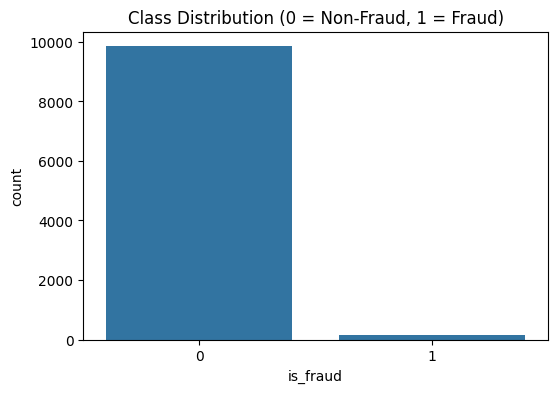

is_fraud
0    0.9849
1    0.0151
Name: proportion, dtype: float64


In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=data['is_fraud'])
plt.title("Class Distribution (0 = Non-Fraud, 1 = Fraud)")
plt.show()

print(data['is_fraud'].value_counts(normalize=True))

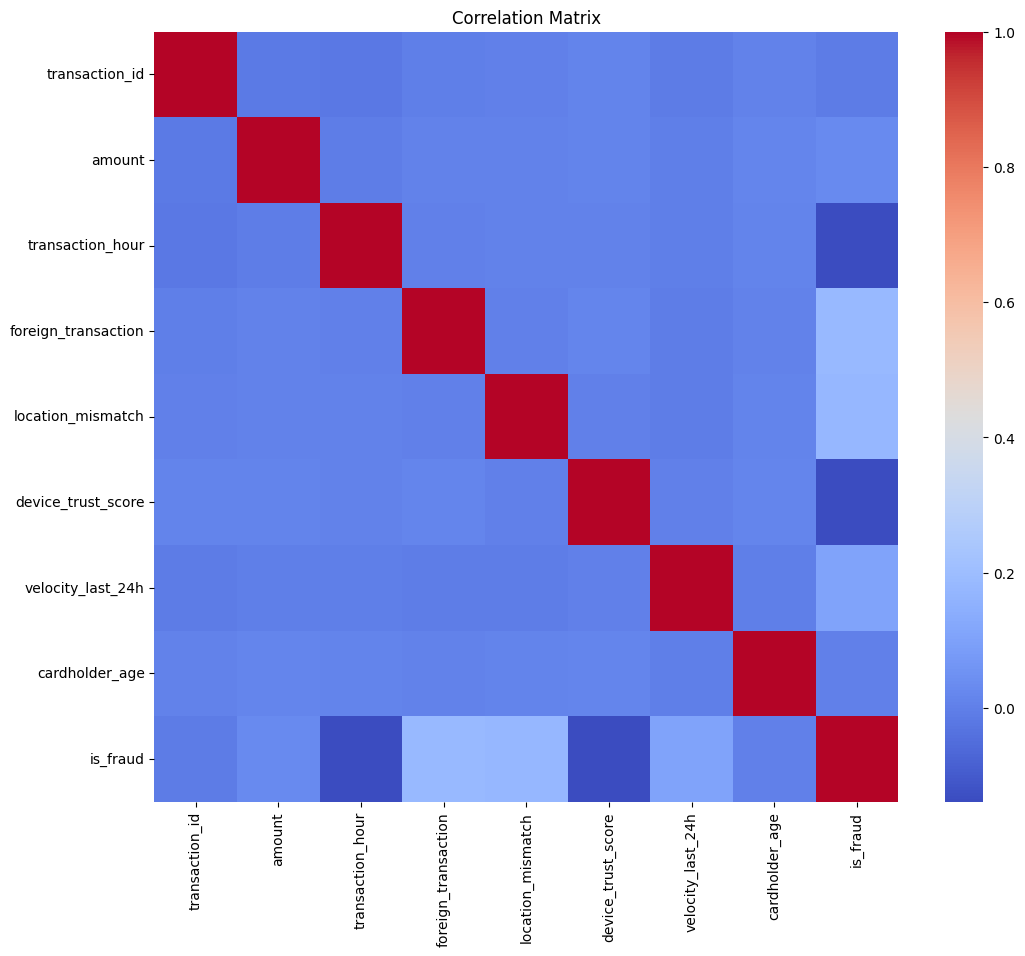

In [93]:
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

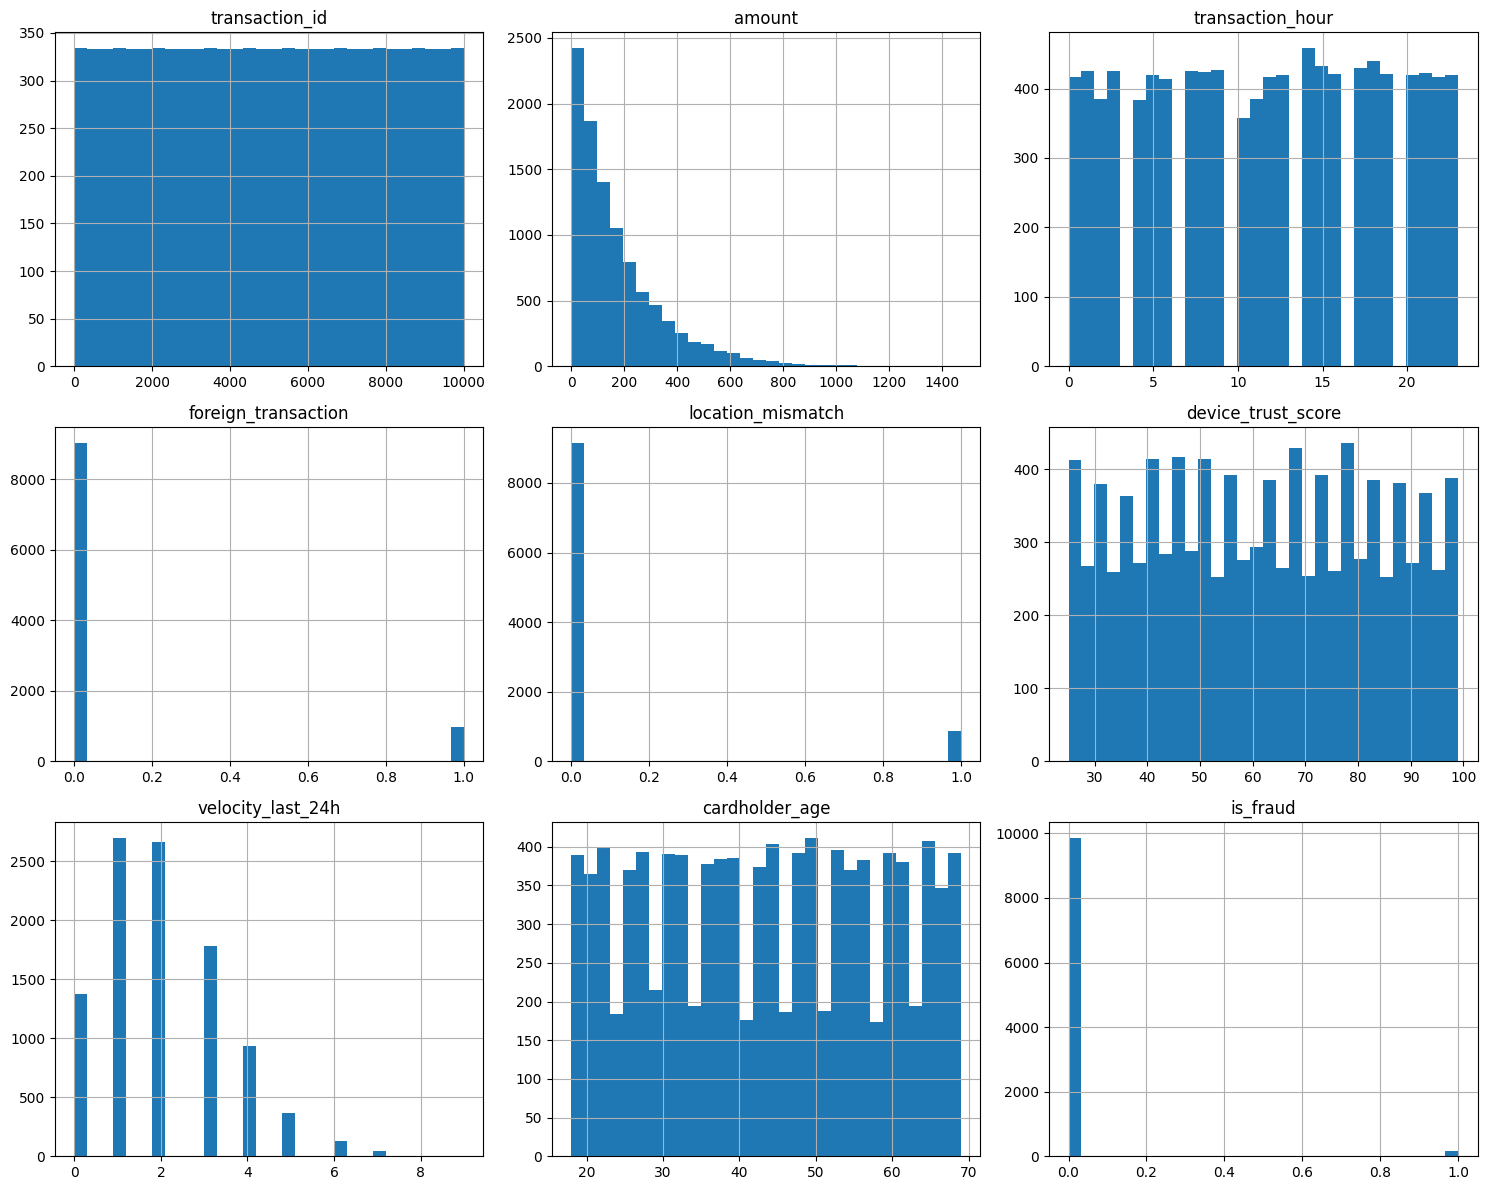

In [94]:
data.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

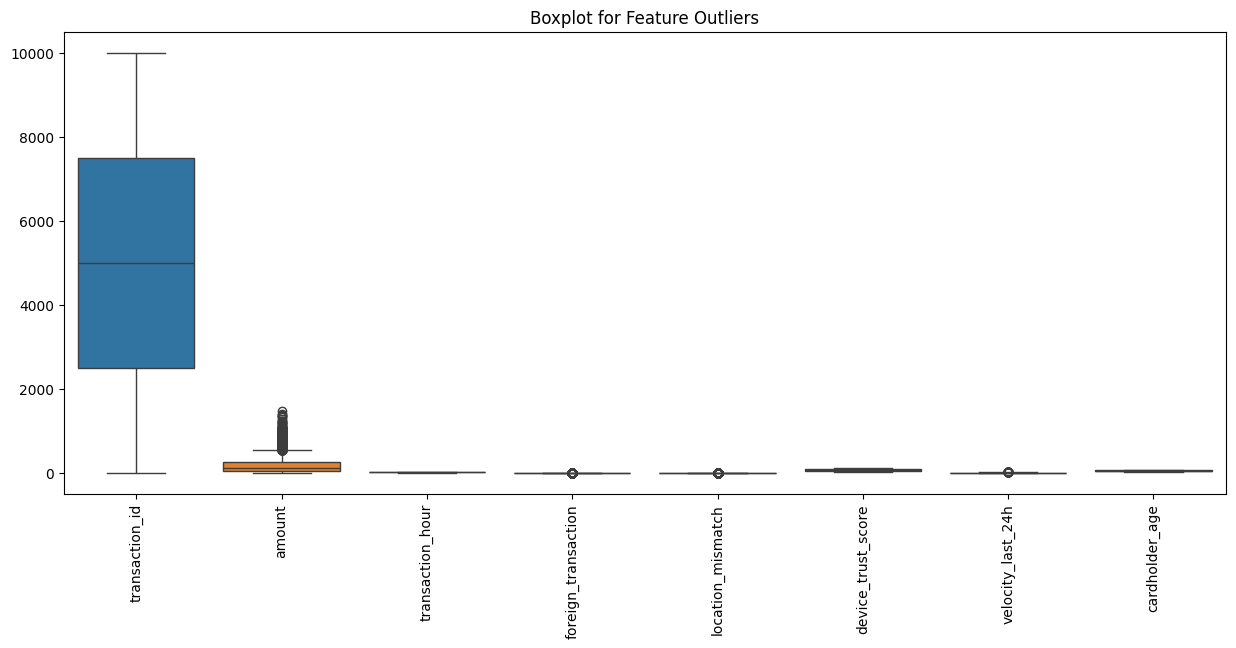

In [95]:
plt.figure(figsize=(15,6))
sns.boxplot(data=data.drop('is_fraud', axis=1))
plt.xticks(rotation=90)
plt.title("Boxplot for Feature Outliers")
plt.show()

In [96]:
fraud = data[data['is_fraud'] == 1]
non_fraud = data[data['is_fraud'] == 0]

print("Fraud transactions:", len(fraud))
print("Non-Fraud transactions:", len(non_fraud))

Fraud transactions: 151
Non-Fraud transactions: 9849


In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

cv = StratifiedKFold(n_splits=5)

log_cv_scores = cross_val_score(log_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print("Logistic Regression CV ROC-AUC:", log_cv_scores.mean())

Logistic Regression CV ROC-AUC: 0.9895621827411167


In [98]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_scaled, y_train)

dt_cv_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print("Decision Tree CV ROC-AUC:", dt_cv_scores.mean())

Decision Tree CV ROC-AUC: 0.966349407783418


In [99]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train)

rf_cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print("Random Forest CV ROC-AUC:", rf_cv_scores.mean())

Random Forest CV ROC-AUC: 0.9997937817258883


In [100]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression")
print(confusion_matrix(y_test, log_preds))
print(classification_report(y_test, log_preds))
print("ROC-AUC:", roc_auc_score(y_test, log_probs))

Logistic Regression
[[1967    2]
 [  16   15]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1969
           1       0.88      0.48      0.62        31

    accuracy                           0.99      2000
   macro avg       0.94      0.74      0.81      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9896623470240339


In [101]:
dt_preds = dt_model.predict(X_test_scaled)
dt_probs = dt_model.predict_proba(X_test_scaled)[:,1]

print("Decision Tree")
print(confusion_matrix(y_test, dt_preds))
print(classification_report(y_test, dt_preds))
print("ROC-AUC:", roc_auc_score(y_test, dt_probs))

Decision Tree
[[1967    2]
 [   3   28]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1969
           1       0.93      0.90      0.92        31

    accuracy                           1.00      2000
   macro avg       0.97      0.95      0.96      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC: 0.9511050312095546


In [102]:
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:,1]

print("Random Forest")
print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))

Random Forest
[[1969    0]
 [  13   18]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1969
           1       1.00      0.58      0.73        31

    accuracy                           0.99      2000
   macro avg       1.00      0.79      0.87      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9994429790789496


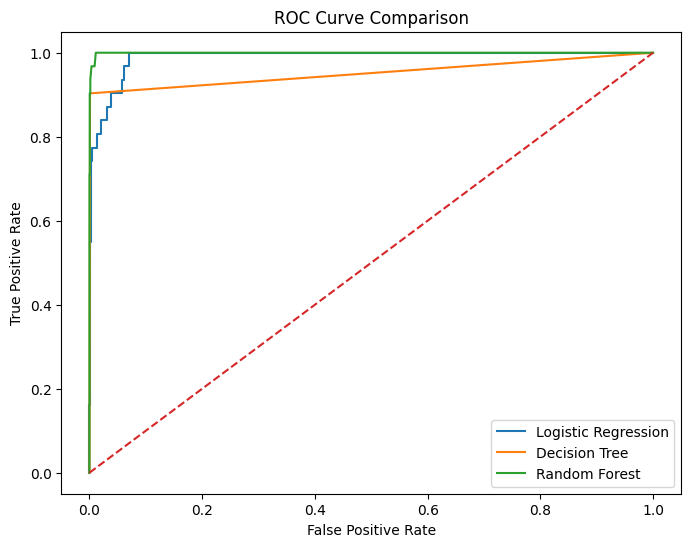

In [103]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
plt.plot(fpr_log, tpr_log, label="Logistic Regression")

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

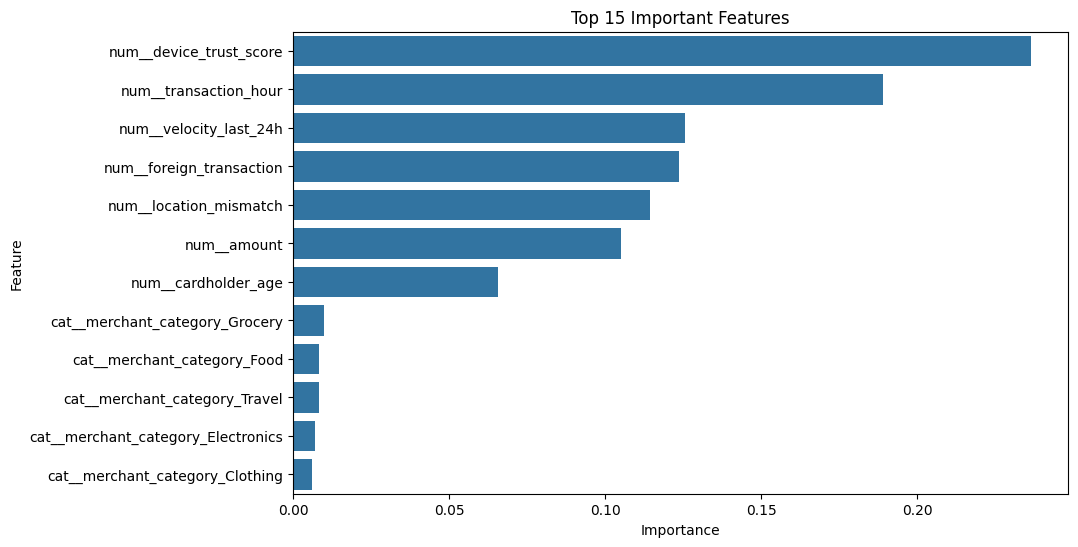

In [104]:
importances = rf_model.feature_importances_

features = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(15))
plt.title("Top 15 Important Features")
plt.show()

In [105]:
print("Final CV Scores:")
print("Logistic Regression:", log_cv_scores.mean())
print("Decision Tree:", dt_cv_scores.mean())
print("Random Forest:", rf_cv_scores.mean())

Final CV Scores:
Logistic Regression: 0.9895621827411167
Decision Tree: 0.966349407783418
Random Forest: 0.9997937817258883
